# Results Comparison: T1 through T5

**CSCI 575 | Privacy-Preserving Record Linkage**

Loads metrics, example-pair predictions, and distribution plots from all five tiers for side-by-side comparison. Run the five tier notebooks first.

- **T1** hand-tuned weighted scorecard (no ML)
- **T2** Gaussian Naive Bayes
- **T3** centralized logistic regression 
- **T4** same LR trained via FedAvg with TTP features (sent plaintext)
- **T5** FedAvg with Bloom-encoded text and salted-hashed structured fields

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display

from utils import (
    RESULTS_DIR, FEATURE_NAMES, EXAMPLE_PAIRS,
    load_candidates, build_feature_matrix,
)

## Metrics Table

Each tier's one-row metrics CSV, stacked. All five tiers evaluate on the same 100k test set.

T1's threshold is 0.70 because its score is a weighted similarity, not a probability - there is no calibration. 0.70 was hand-tuned to sit in the valley of T1's score distribution. T2–T5 output `P(match | x)` directly, so the natural decision boundary is 0.50 (where prior odds flip).

In [2]:
tier_metrics = pd.concat([
    pd.read_csv(RESULTS_DIR / 'tier1_metrics.csv'),
    pd.read_csv(RESULTS_DIR / 'tier2_metrics.csv'),
    pd.read_csv(RESULTS_DIR / 'tier3_metrics.csv'),
    pd.read_csv(RESULTS_DIR / 'tier4_metrics.csv'),
    pd.read_csv(RESULTS_DIR / 'tier5_metrics.csv'),
], ignore_index=True)

tier_metrics.round(4)

,tier,precision,recall,f1,auc_roc,threshold,n_pairs
0,T1_hand_tuned_scorecard,0.9992,0.9071,0.9509,0.995,0.7,100000
1,T2_naive_bayes,0.9992,1.0000,0.9996,1.000,0.5,100000
2,T3_centralized_ml,0.9993,0.9978,0.9985,1.000,0.5,100000
3,T4_federated_ttp,0.9990,0.9917,0.9953,1.000,0.5,100000
4,T5_federated_bloom,0.9998,0.9982,0.9990,1.000,0.5,100000


## Metric Comparison Chart

Y-axis zoomed to [0.90, 1.005] so the gaps between tiers are visible.

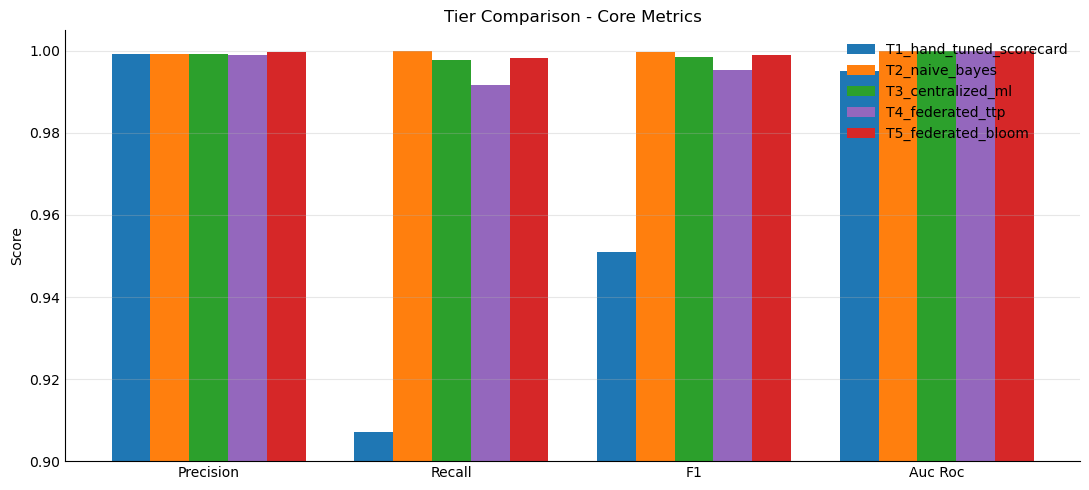

In [3]:
metric_columns = ['precision', 'recall', 'f1', 'auc_roc']
tier_labels    = tier_metrics['tier'].tolist()
x_positions    = np.arange(len(metric_columns))
bar_width      = 0.16
colors         = ['#1f77b4', '#ff7f0e', '#2ca02c', '#9467bd', '#d62728']

plt.figure(figsize=(11, 5))

for tier_index, tier_label in enumerate(tier_labels):
    row    = tier_metrics[tier_metrics['tier'] == tier_label].iloc[0]
    values = [row[metric_name] for metric_name in metric_columns]
    offset = (tier_index - (len(tier_labels) - 1) / 2) * bar_width
    plt.bar(x_positions + offset, values, bar_width, label=tier_label, color=colors[tier_index])

plt.xticks(x_positions, [metric_name.replace('_', ' ').title() for metric_name in metric_columns])
plt.ylim(0.90, 1.005)
plt.ylabel('Score')
plt.title('Tier Comparison - Core Metrics')
plt.legend(frameon=False)

ax = plt.gca()
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.tick_params(length=0)
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(RESULTS_DIR / 'comparison_metrics_bar.png', dpi=150)
plt.show()

## Example Pair Comparison

Three fixed pairs are reused across every tier so the same specific records can be traced end-to-end. For each pair we first show the raw Party A and Party B field values along with the plaintext per-field similarity, then the predictions each tier produced.

In [4]:
candidates              = load_candidates()
field_similarity_scores = build_feature_matrix(candidates)

for label, rec_id_a, rec_id_b in EXAMPLE_PAIRS:
    mask       = (candidates['rec_id_a'] == rec_id_a) & (candidates['rec_id_b'] == rec_id_b)
    pair_index = candidates.index[mask][0]
    row        = candidates.loc[pair_index]

    pair_table = pd.DataFrame({
        'party_a':    [row[f'{f}_a'] for f in FEATURE_NAMES],
        'party_b':    [row[f'{f}_b'] for f in FEATURE_NAMES],
        'similarity': [field_similarity_scores.loc[pair_index, f] for f in FEATURE_NAMES],
    }, index=FEATURE_NAMES).round({'similarity': 3})

    print(f"\n── {label} - rec_id_a={rec_id_a}, rec_id_b={rec_id_b}, is_match={row['is_match']}")
    display(pair_table)


── Clear match - rec_id_a=11841, rec_id_b=11841, is_match=True


,party_a,party_b,similarity
first_name,Sarah,Sarah,1.000
last_name,Evans,Evans,1.000
street_address,050 Ashlee Grove,050 Ashlee Grove,1.000
date_of_birth,1940-07-04,9140-07-04,0.967
email,jennifer78@example.net,jennifer78@example.net,1.000
zip_code,69673,69673,1.000
state,IN,IN,1.000
phone,424-646-5591x4264,424-646-5591x4264,1.000



── Missed match (false negative) - rec_id_a=10516, rec_id_b=10516, is_match=True


,party_a,party_b,similarity
first_name,Amanda,NaN,0.00
last_name,Williams,Wlliams,0.92
street_address,11762 Amanda Crossroad Suite 276,11762 Amanda Crossroad Suite 276,1.00
date_of_birth,1990-04-09,1990-04-09,1.00
email,danacook@example.com,danacook@example.com,1.00
zip_code,10495,10945,0.00
state,MO,MO,1.00
phone,739.785.8166,NaN,0.00



── Non-match - rec_id_a=47135, rec_id_b=39460, is_match=False


,party_a,party_b,similarity
first_name,Vanessa,Margaret,0.490
last_name,Brown,Wagner,0.456
street_address,881 Stewart Common,NaN,0.000
date_of_birth,1961-01-17,1997-01-08,0.678
email,stephenharris@example.com,brittanymedina@example.net,0.660
zip_code,30400,18636,0.000
state,RI,GA,0.000
phone,892.965.1768x91032,468-355-3298x532,0.000


### Per-tier scores and predictions

Each tier's score and prediction for the same three pairs. The cross-tier pivot shows who catches what.

In [5]:
example_predictions = pd.concat([
    pd.read_csv(RESULTS_DIR / 'tier1_example_predictions.csv'),
    pd.read_csv(RESULTS_DIR / 'tier2_example_predictions.csv'),
    pd.read_csv(RESULTS_DIR / 'tier3_example_predictions.csv'),
    pd.read_csv(RESULTS_DIR / 'tier4_example_predictions.csv'),
    pd.read_csv(RESULTS_DIR / 'tier5_example_predictions.csv'),
], ignore_index=True)

comparison_pivot = example_predictions.pivot(
    index   = ['label', 'rec_id_a', 'rec_id_b', 'is_match'],
    columns = 'tier',
    values  = ['score', 'predicted_match'],
).round(3)

comparison_pivot.to_csv(RESULTS_DIR / 'comparison_example_pairs.csv')
comparison_pivot

score  \
tier                                                     T1_hand_tuned_scorecard   
label                         rec_id_a rec_id_b is_match                           
Clear match                   11841    11841    True                       0.993   
Missed match (false negative) 10516    10516    True                       0.700   
Non-match                     47135    39460    False                      0.447   

                                                                         \
tier                                                     T2_naive_bayes   
label                         rec_id_a rec_id_b is_match                  
Clear match                   11841    11841    True                1.0   
Missed match (false negative) 10516    10516    True                1.0   
Non-match                     47135    39460    False               0.0   

                                                                            \
tier                                                     T3_centralized_ml   
label                         rec_id_a rec_id_b is_match                     
Clear match                   11841    11841    True                 1.000   
Missed match (false negative) 10516    10516    True                 0.967   
Non-match                     47135    39460    False                0.000   

                                                                           \
tier                                                     T4_federated_ttp   
label                         rec_id_a rec_id_b is_match                    
Clear match                   11841    11841    True                1.000   
Missed match (false negative) 10516    10516    True                0.534   
Non-match                     47135    39460    False               0.000   

                                                                             \
tier                                                     T5_federated_bloom   
label                         rec_id_a rec_id_b is_match                      
Clear match                   11841    11841    True                  1.000   
Missed match (false negative) 10516    10516    True                  0.832   
Non-match                     47135    39460    False                 0.000   

                                                                 predicted_match  \
tier                                                     T1_hand_tuned_scorecard   
label                         rec_id_a rec_id_b is_match                           
Clear match                   11841    11841    True                         1.0   
Missed match (false negative) 10516    10516    True                         0.0   
Non-match                     47135    39460    False                        0.0   

                                                                         \
tier                                                     T2_naive_bayes   
label                         rec_id_a rec_id_b is_match                  
Clear match                   11841    11841    True                1.0   
Missed match (false negative) 10516    10516    True                1.0   
Non-match                     47135    39460    False               0.0   

                                                                            \
tier                                                     T3_centralized_ml   
label                         rec_id_a rec_id_b is_match                     
Clear match                   11841    11841    True                   1.0   
Missed match (false negative) 10516    10516    True                   1.0   
Non-match                     47135    39460    False                  0.0   

                                                                           \
tier                                                     T4_federated_ttp   
label                         rec_id_a rec_id_b is_match                    
Clear match                   11841    11841    True    

## Score / Probability Distributions

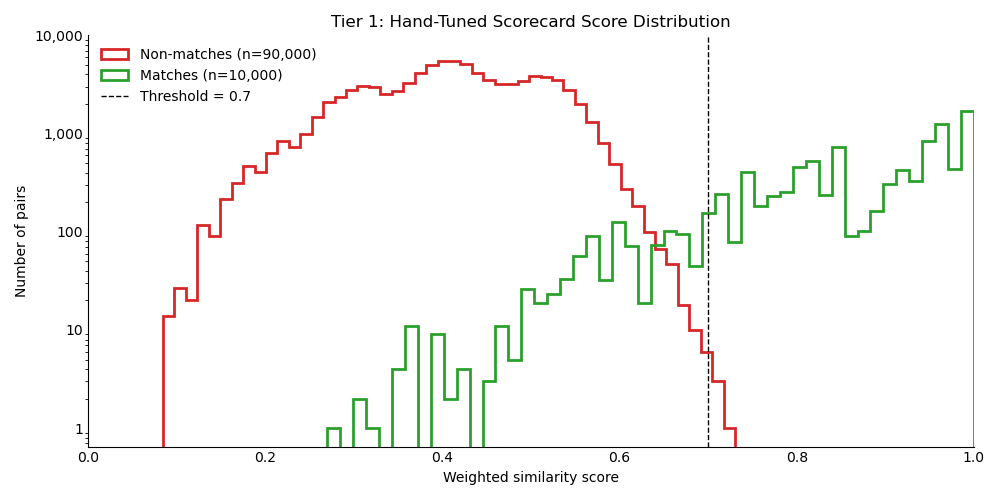

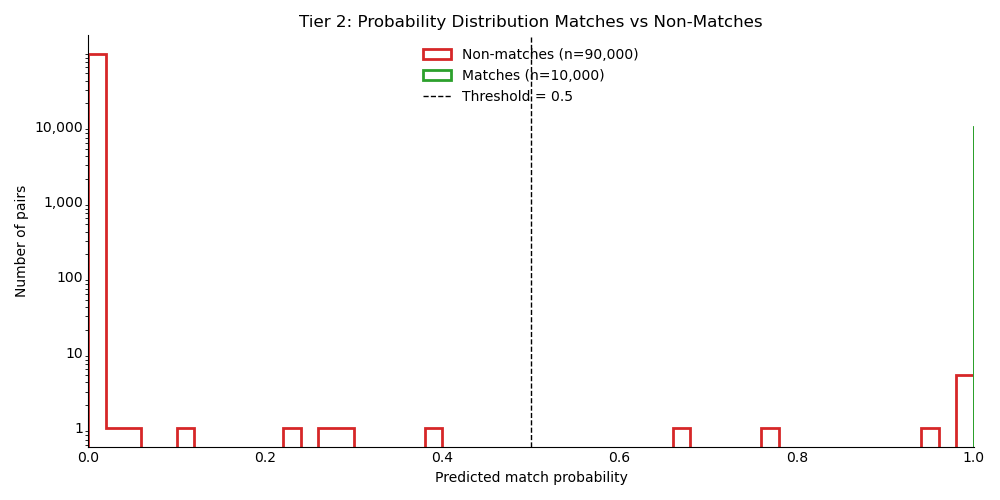

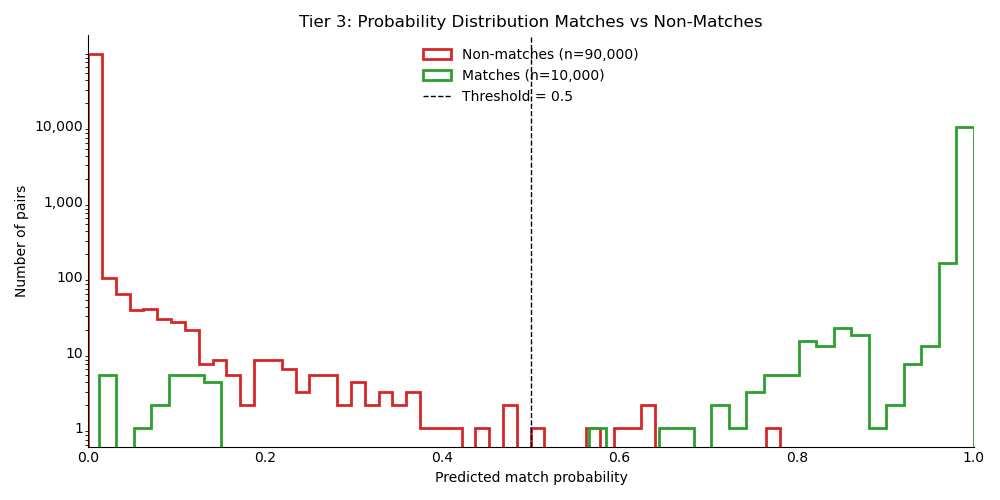

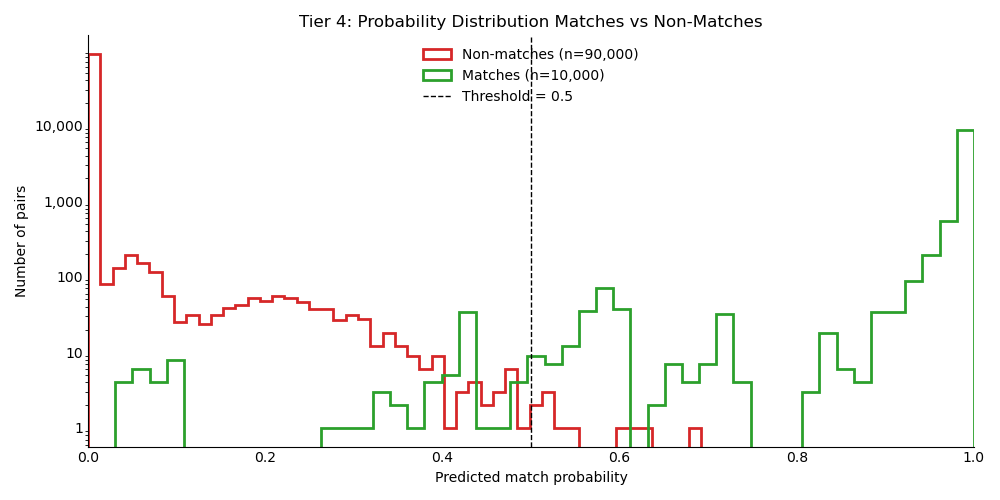

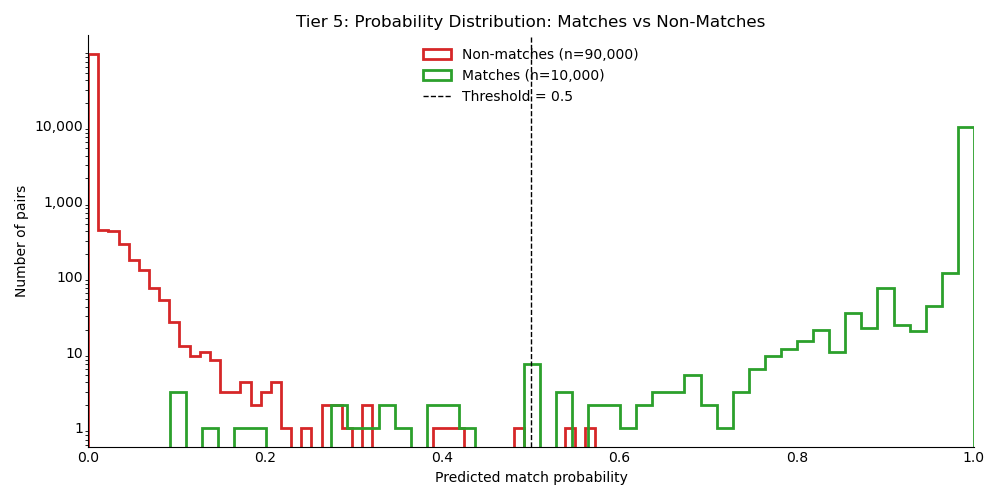

In [6]:
for filename in ['tier1_score_distribution.png',
                 'tier2_score_distribution.png',
                 'tier3_score_distribution.png',
                 'tier4_score_distribution.png',
                 'tier5_score_distribution.png']:
    display(Image(filename=str(RESULTS_DIR / filename)))